In [5]:
!pip install torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 96.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 76.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 56.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 33.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [6]:
import torchvision

Epoch 1/10, Loss: 164.02363803710938
Epoch 2/10, Loss: 114.32112107747396
Epoch 3/10, Loss: 108.31772465820312
Epoch 4/10, Loss: 105.62611469726562
Epoch 5/10, Loss: 104.07560408528646
Epoch 6/10, Loss: 103.0259012858073
Epoch 7/10, Loss: 102.18776502278646
Epoch 8/10, Loss: 101.62279607747396
Epoch 9/10, Loss: 101.14608500976563
Epoch 10/10, Loss: 100.73525737304688


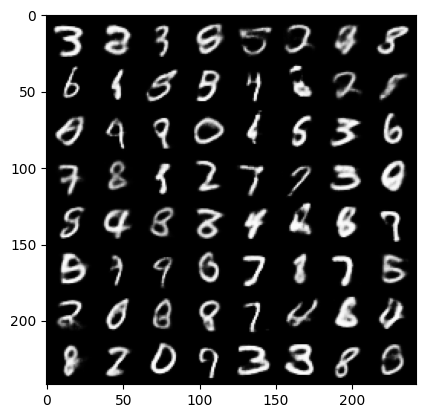

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# VAE Architecture
class VAE(nn.Module):
    def __init__(self, z_dim=20):
        super(VAE, self).__init__()
        self.z_dim = z_dim

        # Encoder network
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 400),
            nn.ReLU(),
        )

        # Latent space
        self.fc_mu = nn.Linear(400, z_dim)  # Mean of latent space
        self.fc_logvar = nn.Linear(400, z_dim)  # Log variance of latent space

        # Decoder network
        self.decoder_fc = nn.Linear(z_dim, 400)
        self.decoder_fc2 = nn.Linear(400, 64 * 7 * 7)
        self.decoder = nn.Sequential(
            nn.ReLU(),
            nn.Unflatten(1, (64, 7, 7)),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()  # Sigmoid to ensure pixel values are between 0 and 1
        )

    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.decoder_fc(z)
        h = self.decoder_fc2(h)
        return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

def loss_function(recon_x, x, mu, logvar):
    # Reshape recon_x to match the target shape
    BCE = nn.BCELoss(reduction='sum')(recon_x.view(-1, 784), x.view(-1, 784))

    # ... (rest of the loss function remains the same)

    # KL divergence between learned latent space and prior (N(0, I))
    # KL divergence = -0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    # Here mu and logvar represent the parameters of the Gaussian distribution
    # we are using for the latent space
    # logvar = log(sigma^2)
    # mu = mean
    # So the KL divergence is computed as:
    # -0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    KL_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return BCE + KL_div

# DataLoader setup
transform = transforms.Compose([
    transforms.ToTensor(),
    # Normalize pixel values to be between 0 and 1
    transforms.Lambda(lambda x: x / 1.0) # divides by the max pixel value
])
train_loader = DataLoader(datasets.MNIST('.', train=True, download=True, transform=transform), batch_size=128, shuffle=True)

# Instantiate model, optimizer
model = VAE(z_dim=20).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Training loop
epochs = 10
for epoch in range(epochs):
    model.train()
    train_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad()

        # Forward pass
        recon_batch, mu, logvar = model(data)

        # Compute loss
        loss = loss_function(recon_batch, data, mu, logvar)

        # Backward pass
        loss.backward()
        train_loss += loss.item()

        optimizer.step()

    print(f'Epoch {epoch + 1}/{epochs}, Loss: {train_loss / len(train_loader.dataset)}')

# Save the trained model
torch.save(model.state_dict(), 'vae_mnist.pth')

# Generate some images after training
model.eval()
with torch.no_grad():
    sample = torch.randn(64, 20).to(device)
    sample = model.decode(sample).cpu()
    grid_img = torchvision.utils.make_grid(sample, nrow=8)
    plt.imshow(grid_img.permute(1, 2, 0))
    plt.show()
